In [1]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [2]:
import torch
import torch.nn as nn

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(10, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

In [6]:
import tensorflow as tf

x = tf.constant([-5.0, 3.0, 10.0])

print(tf.nn.relu(x))

tf.Tensor([ 0.  3. 10.], shape=(3,), dtype=float32)


In [7]:
# ==========================================
# ANN - COMPLETE BASIC EXAMPLE
# ==========================================

import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# ==========================================
# 1. CREATE DATASET
# ==========================================

X = np.array([
    [2, 50, 45],
    [3, 55, 50],
    [4, 60, 55],
    [5, 65, 60],
    [6, 70, 65],
    [7, 75, 70],
    [8, 80, 75],
    [9, 85, 80],
    [10, 90, 85],
    [11, 95, 90],
    [1, 40, 35],
    [3, 45, 42],
    [5, 55, 58],
    [6, 60, 62],
    [7, 68, 72],
    [8, 78, 78],
    [9, 88, 84],
    [10, 92, 88],
    [2, 48, 40],
    [4, 58, 52]
])

# 0 = Fail
# 1 = Pass

y = np.array([
    0, 0, 0, 0, 1,
    1, 1, 1, 1, 1,
    0, 0, 0, 1, 1,
    1, 1, 1, 0, 0
])


# ==========================================
# 2. SPLIT DATA
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ==========================================
# 3. SCALE DATA
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ==========================================
# 4. CREATE ANN MODEL
# ==========================================

model = Sequential([

    # Input + Hidden Layer
    Dense(16, activation="relu", input_shape=(3,)),

    # Hidden Layer
    Dense(8, activation="relu"),

    # Output Layer
    Dense(1, activation="sigmoid")
])


# ==========================================
# 5. COMPILE MODEL
# ==========================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ==========================================
# 6. DISPLAY MODEL
# ==========================================

model.summary()


# ==========================================
# 7. TRAIN MODEL
# ==========================================

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=4,
    validation_split=0.2,
    verbose=1
)


# ==========================================
# 8. EVALUATE MODEL
# ==========================================

loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n==============================")
print("MODEL RESULTS")
print("==============================")

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


# ==========================================
# 9. MAKE PREDICTION
# ==========================================

# New student:
# Study Hours = 8
# Attendance = 85
# Exam Score = 80

new_student = np.array([
    [8, 85, 80]
])

new_student_scaled = scaler.transform(new_student)

prediction = model.predict(new_student_scaled)

print("\n==============================")
print("PREDICTION")
print("==============================")

print("Probability:", prediction[0][0])


if prediction[0][0] >= 0.5:
    print("Prediction: PASS")
else:
    print("Prediction: FAIL")


# ==========================================
# 10. SAVE MODEL
# ==========================================

model.save("ann_student_model.keras")

print("\nModel saved successfully!")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 522ms/step - accuracy: 0.1667 - loss: 0.8408 - val_accuracy: 0.2500 - val_loss: 0.8426
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step - accuracy: 0.1667 - loss: 0.8232 - val_accuracy: 0.2500 - val_loss: 0.8259
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.1667 - loss: 0.8087 - val_accuracy: 0.2500 - val_loss: 0.8099
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.1667 - loss: 0.7951 - val_accuracy: 0.2500 - val_loss: 0.7930
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.1667 - loss: 0.7822 - val_accuracy: 0.5000 - val_loss: 0.7770
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.3333 - loss: 0.7673 - val_accuracy: 0.7500 - val_loss: 0.7618
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5000 - loss: 0.7555 - val_accuracy: 0.7500 - val_loss: 0.7481
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5000 - loss: 0.7434 - val_accuracy: 0.7500 - val_loss: 0

In [8]:
import tensorflow as tf

optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01
)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [9]:
model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32
)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9375 - loss: 0.3576
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9375 - loss: 0.3561
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9375 - loss: 0.3546
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.9375 - loss: 0.3531
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9375 - loss: 0.3516
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9375 - loss: 0.3502
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.9375 - loss: 0.3487
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9375 - loss: 0.3473
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.9375 - loss: 0.3458
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9375 - loss: 0.3444
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9375 - loss: 0.3430
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9375 - loss: 0.34

In [10]:
optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9
)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [11]:
optimizer = tf.keras.optimizers.Adagrad(
    learning_rate=0.01
)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [12]:
optimizer = tf.keras.optimizers.RMSprop(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [13]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [14]:
optimizer="adam"

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=0.01,
        momentum=0.9
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adagrad(
        learning_rate=0.01
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [21]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.9167 - loss: 0.3156 - val_accuracy: 1.0000 - val_loss: 0.2271
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9167 - loss: 0.3131 - val_accuracy: 1.0000 - val_loss: 0.2244
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9167 - loss: 0.3106 - val_accuracy: 1.0000 - val_loss: 0.2217
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9167 - loss: 0.3079 - val_accuracy: 1.0000 - val_loss: 0.2189
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9167 - loss: 0.3053 - val_accuracy: 1.0000 - val_loss: 0.2159
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.9167 - loss: 0.3026 - val_accuracy: 1.0000 - val_loss: 0.2130
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9167 - loss: 0.2998 - val_accuracy: 1.0000 - val_loss: 0.2101
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9167 - loss: 0.2970 - val_accuracy: 1.0000 - val_loss: 0.

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, activation="relu", input_shape=(10,)),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
Dropout(0.3)

<Dropout name=dropout_2, built=True>

In [24]:
from tensorflow.keras.layers import Dense, BatchNormalization

model = Sequential([
    Dense(64, activation="relu", input_shape=(10,)),
    BatchNormalization(),

    Dense(32, activation="relu"),
    BatchNormalization(),

    Dense(1, activation="sigmoid")
])

In [25]:
from tensorflow.keras.layers import Dense, BatchNormalization, Activation

model = Sequential([
    Dense(64, input_shape=(10,)),
    BatchNormalization(),
    Activation("relu"),

    Dense(32),
    BatchNormalization(),
    Activation("relu"),

    Dense(1, activation="sigmoid")
])

In [29]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping


# ==========================================
# 1. CREATE MODEL
# ==========================================

model = Sequential([

    Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(0.001),
        input_shape=(X_train.shape[1],)
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(
        32,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),

    BatchNormalization(),

    Dropout(0.2),

    Dense(
        1,
        activation="sigmoid"
    )
])


# ==========================================
# 2. COMPILE MODEL
# ==========================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ==========================================
# 3. EARLY STOPPING
# ==========================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


# ==========================================
# 4. TRAIN MODEL
# ==========================================

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.5000 - loss: 0.8882 - val_accuracy: 0.2500 - val_loss: 0.7188
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.6667 - loss: 0.6324 - val_accuracy: 0.7500 - val_loss: 0.7106
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 1.0000 - loss: 0.3787 - val_accuracy: 0.7500 - val_loss: 0.7012
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5833 - loss: 0.7339 - val_accuracy: 0.7500 - val_loss: 0.6924
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9167 - loss: 0.4578 - val_accuracy: 0.7500 - val_loss: 0.6835
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9167 - loss: 0.4619 - val_accuracy: 1.0000 - val_loss: 0.6730
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7500 - loss: 0.5907 - val_accuracy: 1.0000 - val_loss: 0.6626
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.7500 - loss: 0.4639 - val_accuracy: 1.0000 - val_loss

In [30]:
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Test Loss: 0.3041609227657318
Test Accuracy: 1.0


In [31]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 1.0000 - loss: 0.0853 - val_accuracy: 1.0000 - val_loss: 0.3053
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step - accuracy: 1.0000 - loss: 0.0578 - val_accuracy: 1.0000 - val_loss: 0.3029
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 1.0000 - loss: 0.0814 - val_accuracy: 1.0000 - val_loss: 0.2999
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 1.0000 - loss: 0.0759 - val_accuracy: 1.0000 - val_loss: 0.2974
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 1.0000 - loss: 0.0706 - val_accuracy: 1.0000 - val_loss: 0.2946
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 1.0000 - loss: 0.1020 - val_accuracy: 1.0000 - val_loss: 0.2919
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 1.0000 - loss: 0.0817 - val_accuracy: 1.0000 - val_loss: 0.2894
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 1.0000 - loss: 0.1257 - val_accuracy: 1.0000 - v

In [32]:
patience=5

In [33]:
restore_best_weights=True

In [34]:
from tensorflow.keras.regularizers import l1

model = Sequential([
    Dense(
        64,
        activation="relu",
        kernel_regularizer=l1(0.001),
        input_shape=(10,)
    ),

    Dense(
        32,
        activation="relu",
        kernel_regularizer=l1(0.001)
    ),

    Dense(1, activation="sigmoid")
])

In [35]:
from tensorflow.keras.regularizers import l2

model = Sequential([
    Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(0.001),
        input_shape=(10,)
    ),

    Dense(
        32,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),

    Dense(1, activation="sigmoid")
])

In [36]:
epochs=10

In [40]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping


# ==========================================
# CHECK DATA
# ==========================================

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


# ==========================================
# CREATE MODEL
# ==========================================

model = Sequential([

    Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(0.001),
        input_shape=(X_train.shape[1],)
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(
        32,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),

    BatchNormalization(),

    Dropout(0.2),

    Dense(
        1,
        activation="sigmoid"
    )
])


# ==========================================
# COMPILE
# ==========================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ==========================================
# SHOW MODEL
# ==========================================

model.summary()


# ==========================================
# EARLY STOPPING
# ==========================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


# ==========================================
# TRAIN
# ==========================================

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

X_train shape: (16, 3)
y_train shape: (16,)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3333 - loss: 1.2400 - val_accuracy: 0.2500 - val_loss: 0.8021
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.6667 - loss: 0.6769 - val_accuracy: 0.2500 - val_loss: 0.7854
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.5000 - loss: 0.8024 - val_accuracy: 0.2500 - val_loss: 0.7709
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.6667 - loss: 0.7214 - val_accuracy: 0.5000 - val_loss: 0.7540
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.6667 - loss: 0.7855 - val_accuracy: 0.5000 - val_loss: 0.7391
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.8333 - loss: 0.5177 - val_accuracy: 0.5000 - val_loss: 0.7245
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8333 - loss: 0.4095 - val_accuracy: 0.5000 - val_loss: 0.7106
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9167 - loss: 0.4537 - val_accuracy: 0.5000 - val_los

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
MODEL PERFORMANCE
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
AUC-ROC   : 1.0000

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


CONFUSION MATRIX
[[2 0]
 [0 2]]


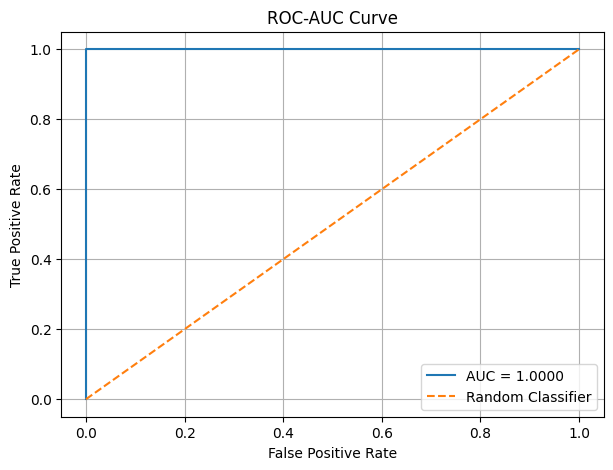

In [41]:
# ==========================================
# MODEL EVALUATION
# Precision, Recall, F1 Score, AUC-ROC
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

# ------------------------------------------
# 1. Predict probabilities
# ------------------------------------------

y_probability = model.predict(X_test)

# Convert probabilities to 0/1 classes
y_pred = (y_probability >= 0.5).astype(int).ravel()

# ------------------------------------------
# 2. Calculate metrics
# ------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

auc = roc_auc_score(y_test, y_probability.ravel())

# ------------------------------------------
# 3. Display results
# ------------------------------------------

print("==========================================")
print("MODEL PERFORMANCE")
print("==========================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC-ROC   : {auc:.4f}")

# ------------------------------------------
# 4. Classification report
# ------------------------------------------

print("\n==========================================")
print("CLASSIFICATION REPORT")
print("==========================================")

print(classification_report(y_test, y_pred))

# ------------------------------------------
# 5. Confusion Matrix
# ------------------------------------------

print("\n==========================================")
print("CONFUSION MATRIX")
print("==========================================")

cm = confusion_matrix(y_test, y_pred)

print(cm)

# ------------------------------------------
# 6. ROC Curve
# ------------------------------------------

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability.ravel()
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")

plt.legend()
plt.grid()
plt.show()